# 05 · The analyst agent, step by step

Same agent as `05_agent_pydantic_ai` (GPT-5.6 Luna on Bedrock, five tools, six skills, one conversation list), but every
question runs through the `agent.iter()` loop from notebook 04, so you watch each model call and each tool call as it
happens, with a preamble sentence before every tool call and a usage + cost line after every model call.

New here:

* **Hard limits per question** (`LIMITS` in section 4): model calls, tool calls, total tokens, dollars. The run stops
  with `UsageLimitExceeded` instead of burning 50 Luna calls on a loop.
* **`run_python` runs alone** (`sequential=True`): two code calls in one model response would race on the same kernel.
* **End-of-question summary**: requests, tool calls, tokens in / cache read / cache write / out / reasoning, cost of
  this question, and the running cost of the whole conversation.

Needs the `aeronet-sandbox` image (notebook 02), this box's instance role, and `pydantic-ai-slim[bedrock,bedrock-mantle]`.

1. Tools · 2. Skills · 3. System prompt · 4. Model, limits, agent · 5. `ask()` = the loop · 6. Try it · 7. Save / resume · 8. Cleanup

In [1]:
import json, os, re, sys
os.environ["PYDANTIC_AI_NO_BANNER"] = "1"
from pathlib import Path
from IPython.display import Image, display
import pandas as pd
import pyarrow.parquet as pq

sys.path.insert(0, "../sandbox")
import sandbox as sb

CONVERSATION_ID = "conv_005"          # container name + folder conversation_data/conv_005/

# 0. Update Pricing

In [2]:
import copy
from decimal import Decimal
import genai_prices.data_snapshot as ds
from genai_prices.types import ModelPrice
from pydantic_ai.usage import RequestUsage
from pydantic_ai._genai_prices import best_effort_price

In [3]:
URL = f"https://bedrock-runtime.us-west-2.amazonaws.com/openai/v1"
MODEL_ID = "us.openai.gpt-5.6-luna"

def _rate(x):                      
    return getattr(x, "base", x)

def show_price(usage=RequestUsage(input_tokens=1_000_000, output_tokens=1_000_000)):
    '''Which price entry Pydantic AI resolves MODEL_ID to right now, its rates, and what `usage` would cost.'''
    p = best_effort_price(usage, model_name=MODEL_ID, provider_api_url=URL)
    if p is None:
        print("no price known for", MODEL_ID); return
    pr = p.model.prices
    if isinstance(pr, list): pr = pr[-1].prices           # date-conditional entries: latest one
    print(f"{'CUSTOM' if ds._custom_snapshot else 'bundled'} table -> {p.provider.id} / {p.model.id}")
    print(f"  USD per M tokens: in {_rate(pr.input_mtok)} | cache read {_rate(pr.cache_read_mtok)} | "
          f"cache write {_rate(pr.cache_write_mtok)} | out {_rate(pr.output_mtok)}")
    print(f"  {usage.input_tokens:,} in + {usage.output_tokens:,} out = ${p.total_price}")

def set_price(input_mtok, cache_read_mtok, cache_write_mtok, output_mtok):
    '''Replace the Luna entry's rates (USD per M tokens) for this Python process.'''
    snap = copy.deepcopy(ds.get_snapshot())
    aws  = next(p for p in snap.providers if p.id == "aws")
    luna = next(m for m in aws.models if m.id == "regional.openai.gpt-5.6-luna")
    luna.prices = ModelPrice(input_mtok=Decimal(str(input_mtok)), cache_read_mtok=Decimal(str(cache_read_mtok)),
                             cache_write_mtok=Decimal(str(cache_write_mtok)), output_mtok=Decimal(str(output_mtok)))
    ds.set_custom_snapshot(ds.DataSnapshot(providers=snap.providers, from_auto_update=False))


In [4]:
show_price()                        # what is in force now
set_price(1.00, 0.10, 1.25, 5.00)   # edit: in, cache read, cache write, out
show_price()                        # should print CUSTOM and the new rates
ds.set_custom_snapshot(None)        # back to the bundled table
show_price()

bundled table -> aws / regional.openai.gpt-5.6-luna
  USD per M tokens: in 0.22 | cache read 0.022 | cache write 0.275 | out 1.32
  1,000,000 in + 1,000,000 out = $2.420
CUSTOM table -> aws / regional.openai.gpt-5.6-luna
  USD per M tokens: in 1.0 | cache read 0.1 | cache write 1.25 | out 5.0
  1,000,000 in + 1,000,000 out = $6.00
bundled table -> aws / regional.openai.gpt-5.6-luna
  USD per M tokens: in 0.22 | cache read 0.022 | cache write 0.275 | out 1.32
  1,000,000 in + 1,000,000 out = $2.420


In [5]:
show_price()

bundled table -> aws / regional.openai.gpt-5.6-luna
  USD per M tokens: in 0.22 | cache read 0.022 | cache write 0.275 | out 1.32
  1,000,000 in + 1,000,000 out = $2.420


## 1 · Tools

Unchanged from `05_agent_pydantic_ai`: three sandbox functions (notebook 03) plus two deterministic host lookups,
`list_sites` and `describe_columns`. The docstring is what the model reads; the type hints become the argument schema.

In [6]:
def run_python(code: str, timeout: int = 60) -> str:
    '''Run Python code in this conversation's sandbox (a persistent IPython kernel) and return what happened.
    Pre-imported: numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns.
    DATA = path of the AERONET AOD Level 2 daily parquet (read-only; Always read a column subset, the full table is ~1 GB; The system where the code executes is very lightweight).
    Variables persist between calls. No network. 2 GB RAM, 2 CPUs.
    What comes back, like a notebook cell:
    - stdout: everything you print(); stderr: warnings.
    - result: the value of the last expression if it is not an assignment (a DataFrame comes back as shape, dtypes,
      head and tail). Assign to a variable to suppress it.
    - stdout, stderr and result are each cut to 4000 characters (middle removed, marked "[N chars clipped]").
      Show only what you need: a small slice, .to_string() on a few rows, or aggregate first. Never print a whole
      table; save it as CSV under /workspace/ and report the file name.
    - Figures: save them yourself with fig.savefig('/workspace/<descriptive_name>.png'); any figure left open is
      auto-saved as fig_NNN.png. No plt.show(). All PNG names written by the cell are returned under figures.
    - new/changed variables with type and shape, files written, elapsed time and memory.
    Write any export (parquet, csv, png) under /workspace/.'''
    if not sb.running(CONVERSATION_ID):
        sb.start(CONVERSATION_ID)
    r = sb.exec_code(CONVERSATION_ID, code, timeout)
    out = []
    if r.get("stdout"):       out.append("stdout:\n" + r["stdout"].rstrip())
    if r.get("stderr"):       out.append("stderr:\n" + r["stderr"].rstrip())
    if r.get("error"):        out.append("ERROR: " + r["error"])
    if r.get("result"):       out.append("result:\n" + r["result"])
    if r.get("figures"):      out.append("figures saved: " + ", ".join(r["figures"]))
    if r.get("new_files"):    out.append("files written: " + ", ".join(r["new_files"]))
    if r.get("vars_new"):     out.append(f"new variables: {r['vars_new']}")
    if r.get("vars_changed"): out.append(f"changed variables: {r['vars_changed']}")
    if "elapsed_s" in r:      out.append(f"[{r['elapsed_s']} s, {r['rss_mb']} MB RSS]")
    return "\n".join(out) or "(no output)"


def kernel_state() -> str:
    '''Variables (type and shape), files in /workspace and memory use of this conversation's sandbox.'''
    return json.dumps(sb.state(CONVERSATION_ID), indent=1)


def reset_kernel() -> str:
    '''Delete all variables and open figures. Files in /workspace are kept.'''
    sb.reset(CONVERSATION_ID)
    return "kernel reset: no variables"


# ── two deterministic tools: computed on the host from the parquet, no LLM, no sandbox ──────────────
_SITES = None

def _sites():
    '''One row per site: location, record span, days with data. Read once (~10 s), then cached.'''
    global _SITES
    if _SITES is None:
        cols = ["AERONET_Site_Name", "Site_Latitude_Degrees", "Site_Longitude_Degrees", "Site_Elevation_m", "date"]
        df = pd.read_parquet(sb.PARQUET, columns=cols)
        g = df.groupby("AERONET_Site_Name")
        _SITES = pd.DataFrame({"lat": g["Site_Latitude_Degrees"].first().round(3),
                               "lon": g["Site_Longitude_Degrees"].first().round(3),
                               "elev_m": g["Site_Elevation_m"].first().round(0).astype(int),
                               "first": g["date"].min().dt.strftime("%Y-%m-%d"),
                               "last": g["date"].max().dt.strftime("%Y-%m-%d"),
                               "days": g.size()}).sort_values("days", ascending=False)
    return _SITES


def list_sites(name_contains: str = "", min_days: int = 0, limit: int = 40) -> str:
    '''Find AERONET sites. Returns name, latitude, longitude, elevation (m), first and last day with data, and the
    number of days with Level 2.0 data, sorted by record length. name_contains is case-insensitive
    (e.g. "kanpur", "GSFC", "_Island"). Use this before any site analysis to get the exact site name.'''
    s = _sites()
    if name_contains:
        s = s[s.index.str.contains(name_contains, case=False, regex=False)]
    s = s[s["days"] >= min_days]
    if s.empty:
        return f"no site matches name_contains={name_contains!r}, min_days={min_days}; try a shorter fragment"
    head = f"{len(s)} site(s) match" + (f", showing the {limit} with the longest records" if len(s) > limit else "") + "\n"
    return head + s.head(limit).to_string()


def _describe(col):
    if m := re.fullmatch(r"AOD_(\d+)nm", col):                       return f"aerosol optical depth at {m[1]} nm (unitless)"
    if m := re.fullmatch(r"Angstrom_Exponent_(\d+)_(\d+)nm(_Polar)?", col):
        return f"Ångström exponent {m[1]}–{m[2]} nm" + (" (polar instrument)" if m[3] else "")
    if m := re.fullmatch(r"N_(.+)", col):                             return f"number of measurements in the daily {m[1]}"
    return {"AERONET_Site_Name": "site name", "datetime_utc": "day stamp, 12:00 UTC", "date": "day",
            "year": "year", "month": "month", "Day_of_Year": "day of year 1–366",
            "Site_Latitude_Degrees": "latitude (deg)", "Site_Longitude_Degrees": "longitude (deg)",
            "Site_Elevation_m": "elevation (m)", "Precipitable_Water_cm": "column water vapour (cm)",
            "Data_Quality_Level": "always lev20", "AERONET_Instrument_Number": "sun-photometer id",
            "PI": "site principal investigator", "PI_Email": "PI e-mail"}.get(col, "")


def describe_columns(site: str = "") -> str:
    '''Columns of the AERONET table with meaning, dtype and how many days have a value.
    Without a site: every column (all sites). With a site (exact name from list_sites): only the columns that site
    has data for — call it once per site before choosing a wavelength. The N_<column> measurement-count columns
    are not listed one by one; every value column has one.'''
    pf = pq.ParquetFile(sb.PARQUET)
    if site:
        t = pq.read_table(sb.PARQUET, filters=[("AERONET_Site_Name", "==", site)])
        if t.num_rows == 0:
            return f"no site named {site!r}; use list_sites to find the exact name"
        n_days, nulls = t.num_rows, {c: t.column(c).null_count for c in t.column_names}
    else:
        n_days = pf.metadata.num_rows
        nulls = {c: 0 for c in pf.schema_arrow.names}
        for rg in range(pf.metadata.num_row_groups):
            for i in range(pf.metadata.num_columns):
                col = pf.metadata.row_group(rg).column(i)
                nulls[col.path_in_schema] += col.statistics.null_count if col.statistics else 0
    where = f"site {site}" if site else "all sites"
    lines = [f"{where}: {n_days} rows (site-days)" + ("; columns with no value at this site omitted" if site else ""),
             f"{'column':34} {'dtype':13} {'days_with_value':>15} {'cover':>6}  meaning"]
    for c in pf.schema_arrow.names:
        if c.startswith("N_"):
            continue
        have = n_days - nulls[c]
        if site and have == 0:
            continue
        lines.append(f"{c:34} {str(pf.schema_arrow.field(c).type):13} {have:>15} {100 * have / n_days:>5.1f}%  {_describe(c)}")
    lines.append("N_<column> (int16): number of Level 2.0 measurements averaged into that day's value; one per AOD, "
                 "Angstrom and Precipitable_Water column (0 -> value is NaN)")
    return "\n".join(lines)


## 2 · Skills

Unchanged. Six written procedures, sent as text in the system prompt on every call (cached).

In [7]:
SKILLS = {}

SKILLS["data_access"] = """
WHEN: the first step of every analysis, before any statistic.
1. list_sites(name_contains=...) gives the exact site name (case-sensitive, underscores: "Mauna_Loa"), coordinates
   and record span; describe_columns(site=...) shows which wavelengths that site has and on how many days.
   Then load only the columns you need, filtered by site, e.g.
   pd.read_parquet(DATA, columns=["AERONET_Site_Name","date","year","month","AOD_500nm","N_AOD_500nm"],
                   filters=[("AERONET_Site_Name","==","GSFC")])
2. Describe the record before using it: days per year, gaps, and the coverage of the wavelength you chose (every
   column is NaN where that wavelength was not measured or failed Level 2.0 screening).
   Coverage is uneven: instruments are moved, break, and are recalibrated; gaps are normal, not errors.
3. One row = one day (daily mean of all Level 2.0 measurements of that day, stamped 12:00 UTC). N_<col> is how
   many measurements went into that mean; a day with N=1 is a real but weak estimate — say so if it matters.
4. Level 2.0 = cloud-screened AND quality-assured with final calibration (Version 3, Giles et al. 2019). You do not
   need extra cloud screening. Do not "clean" outliers: high AOD days are real events (dust, smoke).
5. Wavelengths: 500 nm is the standard reporting wavelength; 440/675/870/1020 nm are on every instrument;
   340/380 nm and 1640 nm only on some. AOD_531nm and AOD_551nm etc. are rarely populated. Check before use.
6. Keep memory small: never load all 73 columns for all sites at once (~1 GB); aggregate per site, then combine.
"""

SKILLS["climatology"] = """
WHEN: "typical", "average", "seasonal cycle", "monthly/annual mean", "how much AOD at site X".
1. Aggregate daily -> monthly means only when the month has enough days; default rule: >= 5 daily values per
   calendar month, and an annual mean needs >= 9 valid months. State the rule you used and how many months/years
   it removed.
2. AOD is right-skewed (roughly log-normal): report mean AND median (and the 10th/90th percentiles when
   describing variability). Use the mean for comparison with satellite/model climatologies, the median for
   "typical day". Ångström exponent is roughly symmetric; the mean is fine.
3. Seasonal cycle = group by calendar month across all years (multi-year monthly climatology); show N years per
   month. Standard deviation across years = interannual variability; std of daily values within the month = day-to-day
   variability. Say which one you plotted.
4. Multi-year climatologies over a changing record are biased if some years are missing whole seasons: check that
   each month-of-year is represented by a similar number of years, otherwise say so.
5. Plot: line or bar of the 12 monthly values with error bars (std or IQR), y-axis label "AOD 500 nm", title with
   site name and period, N per month annotated or in a table. Save under /workspace.
"""

SKILLS["trend"] = """
WHEN: "trend", "is AOD increasing/decreasing", "change over years", "long-term".
1. Requirements: >= 8 years of data with >= 9 valid months each; otherwise say the record is too short and stop at
   a description. Check for large gaps or an instrument change (AERONET_Instrument_Number) that splits the record.
2. Remove the seasonal cycle first: monthly means (>= 5 days) -> monthly anomalies = value minus the multi-year
   mean of that calendar month. Fit the trend to the anomaly time series with time in decimal years, NaN months
   dropped.
3. Use the Theil–Sen slope with the Mann–Kendall test (robust to the skewed distribution and outliers):
     from scipy import stats
     slope, intercept, lo, hi = stats.theilslopes(y, t, alpha=0.95)     # slope + 95 % confidence interval
     tau, p = stats.kendalltau(t, y)                                     # Mann–Kendall on a time series
   Cross-check with OLS that allows for autocorrelated residuals:
     import statsmodels.api as sm
     ols = sm.OLS(y, sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
   Report the OLS slope and its HAC p-value next to the Theil–Sen result; if they disagree on significance, say so.
4. Report: slope in AOD per year AND in % per year relative to the record mean, the confidence interval, n months
   used, p-value, the period. "Significant" = p < 0.05, and say so explicitly either way.
5. Caveats to state: monthly anomalies are autocorrelated (the Kendall p is optimistic, the HAC p is the honest
   one); a trend can be driven by the first or last years — plot the anomalies with the fitted line and look;
   attribution (emissions, dust, fires) is outside the data — do not claim causes.
"""

SKILLS["aerosol_type"] = """
WHEN: "what kind of aerosol", "dust or smoke", "fine vs coarse", "Ångström exponent", "AOD at 550 nm".
1. Use the Angstrom_Exponent_440_870nm column (computed per measurement from the spectral AOD, then averaged);
   do not recompute it from daily-mean AODs unless it is missing.
2. Interpretation (rule of thumb, Eck et al. 1999; Dubovik et al. 2002): AE < 0.75 -> coarse-mode dominated
   (desert dust, sea salt); AE > 1.5 -> fine-mode dominated (smoke, urban/industrial pollution); 0.75–1.5 -> mixed.
   Combined with AOD: high AOD (>= 0.4 at 500 nm) & low AE = dust event; high AOD & high AE = biomass burning or
   pollution; low AOD (< 0.1) & low AE = clean marine or background.
3. AE is noisy when AOD is low: exclude days with AOD_440nm < 0.15 before classifying, and say how many days that
   removed.
4. Show the AOD–AE relationship as a scatter (x = AE 440–870, y = AOD 500 nm, log y), colored by month or season,
   plus a table of the fraction of days in each class. This is a classification of daily means, not of single plumes.
5. AOD at a wavelength that is not measured (e.g. 550 nm): Ångström power law
   AOD(l) = AOD(500) * (l/500) ** (-AE) with AE = Angstrom_Exponent_440_870nm; valid only for 440–870 nm.
   Say that the value is interpolated.
"""

SKILLS["episodes"] = """
WHEN: "event", "episode", "extreme days", "dust storm", "smoke", "when was AOD highest".
1. "High" must be relative to the site's own climatology: flag a day when AOD 500 nm exceeds the site's
   multi-year 95th percentile for that calendar month (default), or a fixed value the user gives. State the
   threshold.
2. Group consecutive flagged days into episodes; report start, end, duration, peak AOD and its date, mean AE
   during the episode (for the likely aerosol type, see the aerosol_type skill), and N days.
3. Rank episodes by peak or by cumulative AOD above the threshold; list the top 10 as a table.
4. Show the daily series for the year(s) of interest with the threshold line and the episodes shaded.
5. A missing day inside an episode is likely cloud (no Level 2.0 data), not a gap in the event; say so rather than
   splitting the episode, unless the gap is > 2 days.
6. Do not name the source (a specific fire, storm) — the data cannot show it; describe timing, magnitude and type.
"""

SKILLS["site_comparison"] = """
WHEN: two or more sites, "compare", "regional", "which site is dustier", "difference between".
1. Compare only over the overlapping period and the same wavelength; state the common period and N days per site.
   If overlap < 2 years, compare climatologies instead and say they are from different years.
2. Report per site: coordinates, elevation, period, N, mean, median, 90th percentile of AOD 500 nm and mean AE
   440–870; then the difference of means/medians. Elevation matters: a mountain site (Mauna_Loa, Izana, > 2 km)
   sees only the free troposphere and is not comparable with a surface site nearby.
3. For paired daily differences use only days both sites have data (inner join on date).
4. Plots: same y-axis for all sites; monthly climatology lines on one axis, or box plots per site; a map (lon/lat
   scatter with site names) helps when there are more than 3 sites.
5. Distances between sites (haversine) belong in the answer when the user asks about "nearby".
"""

SKILLS_TEXT = "\n".join(f"### skill: {name}\n{text.strip()}\n" for name, text in SKILLS.items())
print(f"{len(SKILLS)} skills, {len(SKILLS_TEXT.split())} words")

6 skills, 1273 words


## 3 · System prompt

Rules, data dictionary, sandbox environment, skills, exactly as before, plus the **preamble rule** from notebook 04:
one plain sentence before every batch of tool calls. Bedrock exposes no reasoning text, so this sentence is the only
window into what the model intends. Nothing is injected by code; the model writes it as a `TextPart` in front of its
`ToolCallPart`s and the run continues because tool calls are present.

In [8]:
RULES = """
You are an atmospheric scientist analysing AERONET Level 2.0 aerosol optical depth (AOD) data with Python.
The data is a single parquet table in a sandbox you reach through the run_python tool. Work like an analyst:
- Look at the data before answering. Start with list_sites (exact name, coordinates, record span) and
  describe_columns(site) (which wavelengths that site measured); write code for the analysis, not for that.
  Never guess numbers.
- Follow the matching skill below step by step; say which skill and which thresholds you used.
- Small steps: one run_python call per step, check the output, then continue. Variables persist between calls.
- Tool output is cut at 4000 characters per field: print summaries and small slices, never whole tables;
  the last expression of a cell is returned as result, so end a cell with the object you want to see.
- Every answer states: site(s), coordinates, period used, wavelength, N (days/months/years), method, and caveats.
  AOD to 3 decimals, Ångström exponent to 2. "No data" is not zero.
- Figures: axis labels with units, title with site and period, legend; save each with fig.savefig under
  /workspace with a descriptive name and give the file name.
  Save tables you produce as CSV under /workspace and give the file name.
- Do not attribute causes (specific fires, policies, storms) that the data cannot show.
- If the question cannot be answered from this table (no such site, period outside the record, needs other data),
  say so plainly instead of approximating.
- AERONET data policy: results using a site's data should acknowledge the site PI (columns PI, PI_Email).
"""

DATA_DICTIONARY = """
### data dictionary — /data/aeronet.parquet (AERONET Version 3, Level 2.0, daily averages, all sites)
One row per site and day. Column names are AERONET's with ( ) [ ] - replaced by _.
- AERONET_Site_Name (str), Site_Latitude_Degrees, Site_Longitude_Degrees (decimal degrees), Site_Elevation_m (m)
- datetime_utc (12:00 UTC), date (datetime), year, month, Day_of_Year
- AOD_<λ>nm: aerosol optical depth at λ nm, unitless; NaN = not measured that day or failed Level 2.0 screening.
  Wavelengths present: 340, 380, 400, 412, 440, 443, 490, 500, 510, 532, 551, 555, 560, 620, 667, 675, 681, 709,
  779, 865, 870, 1020, 1640 (most sites: 340, 380, 440, 500, 675, 870, 1020).
- Angstrom_Exponent_<λ1>_<λ2>nm: Ångström exponent between λ1 and λ2 (340_440, 380_500, 440_675, 440_870,
  500_870; 440_675nm_Polar for polar instruments), unitless.
- Precipitable_Water_cm: column water vapour, cm.
- N_<column>: number of Level 2.0 measurements averaged into that day's value (0 -> value is NaN).
- Data_Quality_Level (always "lev20"), AERONET_Instrument_Number (sun-photometer id; changes = instrument swap),
  PI, PI_Email (site principal investigator).
"""

def environment_block():
    env = sb.start(CONVERSATION_ID)            # (re)starts the container and returns its /env
    return ("### sandbox environment\n"
            f"python {env['python']}; packages: " + ", ".join(f"{k} {v}" for k, v in env["packages"].items()) + "\n"
            f"limits: {env['memory_limit_mb']} MB RAM, {env['cpus']} CPUs, {env['workspace_cap_gb']} GB in /workspace, no network\n"
            f"pre-loaded in the kernel:\n{env['preloaded']}\n")

PREAMBLE_RULE = """
### before every tool call
Whenever you call tools, first write ONE short sentence as normal text, before the tool calls, saying what you are
about to do and why. Several tools at once get a single sentence. Never call a tool without that sentence.
"""

INSTRUCTIONS = "\n".join([RULES.strip(), DATA_DICTIONARY.strip(), environment_block(),
                          "### skills\n" + SKILLS_TEXT, PREAMBLE_RULE.strip()])
print(f"{len(INSTRUCTIONS.split())} words ≈ {len(INSTRUCTIONS) // 4} tokens")

1797 words ≈ 2833 tokens


In [9]:
print(INSTRUCTIONS)

You are an atmospheric scientist analysing AERONET Level 2.0 aerosol optical depth (AOD) data with Python.
The data is a single parquet table in a sandbox you reach through the run_python tool. Work like an analyst:
- Look at the data before answering. Start with list_sites (exact name, coordinates, record span) and
  describe_columns(site) (which wavelengths that site measured); write code for the analysis, not for that.
  Never guess numbers.
- Follow the matching skill below step by step; say which skill and which thresholds you used.
- Small steps: one run_python call per step, check the output, then continue. Variables persist between calls.
- Tool output is cut at 4000 characters per field: print summaries and small slices, never whole tables;
  the last expression of a cell is returned as result, so end a cell with the object you want to see.
- Every answer states: site(s), coordinates, period used, wavelength, N (days/months/years), method, and caveats.
  AOD to 3 decimals, Ång

## 4 · Model, limits, agent

Same model path as VAYU (Responses API on `bedrock-runtime`, bearer token from the instance role, 12 h validity).

`LIMITS` is checked by Pydantic AI after every model response. `request_limit` is the loop depth: each model call is
one request, and a retry is also a request. `cost_limit` works because the price table knows `gpt-5.6-luna`
(0.44 / 1.32 USD per M tokens in / out, cached input 0.044). `retries=2` is only for malformed tool arguments and
`ModelRetry`; a Python error inside the sandbox comes back to the model as an `ERROR:` string and costs a normal
request, which is why `request_limit` matters.

In [10]:
from aws_bedrock_token_generator import provide_token
from pydantic_ai import Agent, Tool, UsageLimits, UsageLimitExceeded, RunUsage
from pydantic_ai.models.bedrock_mantle import BedrockMantleResponsesModel, BedrockMantleProvider
from pydantic_ai.models.openai import OpenAIResponsesModelSettings

REGION           = "us-west-2"
BASE_URL         = f"https://bedrock-runtime.{REGION}.amazonaws.com/openai/v1"
MODEL_ID         = "us.openai.gpt-5.6-luna"
REASONING_EFFORT = "medium"          # none | low | medium | high | xhigh | max

LIMITS = UsageLimits(
    request_limit      = 8,        # model calls per question (loop depth)
    tool_calls_limit   = 12,       # successful tool executions per question
    total_tokens_limit = 250_000,  # in + out, cumulative over the question
    cost_limit         = 0.10,     # USD per question
)
TOOL_TIMEOUT = 120                 # seconds; a slower tool = failure + retry prompt to the model

model = BedrockMantleResponsesModel(
    MODEL_ID,
    provider=BedrockMantleProvider(base_url=BASE_URL, api_key=provide_token(region=REGION)),
    settings=OpenAIResponsesModelSettings(max_tokens=8000, openai_reasoning_effort=REASONING_EFFORT,
                                          openai_prompt_cache_key="aeronet:v1"),
)

TOOLS = [Tool(run_python,   sequential=True),    # never two code calls at once on one kernel
         Tool(reset_kernel, sequential=True),
         kernel_state, list_sites, describe_columns]

agent = Agent(model, instructions=INSTRUCTIONS, tools=TOOLS, retries=2, tool_timeout=TOOL_TIMEOUT)
print(model.model_name, "via", model.client.base_url)

us.openai.gpt-5.6-luna via https://bedrock-runtime.us-west-2.amazonaws.com/openai/v1/


## 5 · `ask()` = the loop

`agent.iter()` yields one node per step: `ModelRequestNode` (about to call the model; its parts are the tool results
going in), `CallToolsNode` (the model answered; preamble, tool calls, usage), `End` (final text). Everything is printed
as it completes. `history` is the conversation; the turn is appended only if it finished, so a limit hit leaves the
conversation clean and you can re-ask with a higher limit. `TOTAL` accumulates every finished turn.

In [11]:
from pydantic_graph import End
from pydantic_ai.messages import (ModelRequest, ModelResponse, UserPromptPart, TextPart, ThinkingPart,
                                  ToolCallPart, ToolReturnPart, RetryPromptPart)


def show_part(p, preamble=False):
    if   isinstance(p, UserPromptPart): print(f"  >>> USER        : {p.content}")
    elif isinstance(p, ThinkingPart):   print(f"  ... THINKING    : {(p.content or '<no text>')}")
    elif isinstance(p, TextPart):       print(f"  <<< {'PREAMBLE' if preamble else 'ANSWER  '}    : {p.content}")
    elif isinstance(p, ToolCallPart):   print(f"  --> TOOL CALL   : {p.tool_name}({str(p.args)})")
    elif isinstance(p, ToolReturnPart): print(f"  <-- TOOL RESULT : {p.tool_name} -> {str(p.content)}")
    elif isinstance(p, RetryPromptPart):print(f"  !!! RETRY       : {p.tool_name}: {str(p.content)}")

def usage_line(u):
    cost = f"${u.cost:.4f}" if u.cost is not None else "cost n/a"
    return (f"in {u.input_tokens} (cache read {u.cache_read_tokens}, write {u.cache_write_tokens}) | "
            f"out {u.output_tokens} (reasoning {u.details.get('reasoning_tokens', 0)}) | {cost}")

def show_figures(messages):
    for m in messages:
        if isinstance(m, ModelRequest):
            for p in m.parts:
                if isinstance(p, ToolReturnPart) and isinstance(p.content, str):
                    for line in p.content.splitlines():
                        if line.startswith("figures saved: "):
                            for f in line[len("figures saved: "):].split(", "):
                                display(Image(sb.CONV_DIR / CONVERSATION_ID / f))

history = []
TOTAL   = RunUsage()

async def ask(question, limits=LIMITS):
    step = 0
    print(f"=== {question}")
    try:
        async with agent.iter(question, message_history=history, usage_limits=limits) as run:
            async for node in run:
                if Agent.is_model_request_node(node):
                    step += 1
                    print(f"\n--- step {step}: to model")
                    for p in node.request.parts: show_part(p)
                elif Agent.is_call_tools_node(node):
                    m = node.model_response
                    print(f"--- step {step}: from model")
                    for p in m.parts: show_part(p, preamble=bool(m.tool_calls))
                    print(f"      {usage_line(m.usage)}")
                elif isinstance(node, End):
                    print(f"\n=== ANSWER\n{node.data.output}")
    except UsageLimitExceeded as e:
        print(f"\n=== STOPPED: {e}\n    (turn not added to history; raise the limit or re-ask)")
        return None

    result = run.result
    history.extend(result.new_messages())
    show_figures(result.new_messages())

    u = result.usage
    TOTAL.incr(u)
    print(f"\n=== THIS QUESTION : {u.requests} model calls, {u.tool_calls} tool calls | {usage_line(u)}")
    print(f"=== CONVERSATION  : {TOTAL.requests} model calls, {TOTAL.tool_calls} tool calls | {usage_line(TOTAL)}")
    return result

In [12]:
import re, base64, mimetypes
from IPython.display import Markdown

def render(text):
    '''Model markdown -> displayable markdown: sandbox:/workspace/X links become real files, PNGs inline.'''
    def sub(m):
        label, name = m.group(1), m.group(2)
        f = sb.CONV_DIR / CONVERSATION_ID / name
        if f.suffix.lower() in (".png", ".jpg", ".jpeg") and f.exists():
            b64 = base64.b64encode(f.read_bytes()).decode()
            return f"![{label}](data:{mimetypes.guess_type(name)[0]};base64,{b64})"
        return f"`{f}`" + ("" if f.exists() else " (missing)")
    return re.sub(r"\[([^\]]*)\]\(sandbox:/workspace/([^)\s]+)\)", sub, text)

def answer(result):
    '''Pretty view of one finished question.'''
    display(Markdown(render(result.output)))

## 6 · Try it

One cell at a time. Top-level `await` works in Jupyter. The second question is a follow-up and only makes sense because
`history` carries the first. Pass `limits=UsageLimits(request_limit=3)` to test the stop, or a bigger one for a long analysis.

In [13]:
r = await ask("Which five sites have the longest AOD 500 nm records, and how many days of data does each have?")

=== Which five sites have the longest AOD 500 nm records, and how many days of data does each have?

--- step 1: to model
  >>> USER        : Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll identify the longest-record sites first, then verify that each measured AOD at 500 nm before counting valid daily AOD values.
  --> TOOL CALL   : list_sites({"limit":10})
      in 3664 (cache read 0, write 3662) | out 131 (reasoning 76) | $0.0012

--- step 2: to model
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 10 with the longest records
                      lat      lon  elev_m       first        last  days
AERONET_Site_Name                                                       
Mauna_Loa          19.536 -155.577    3402  1994-06-03  2026-07-07  9198
GSFC               38.992  -76.840      87  1993-05-14  2026-01-08  8234
SEDE_BOKER         30.855   3

In [14]:
sb.state(CONVERSATION_ID)

{'vars': {'cols': 'list',
  'df500': 'DataFrame(1419960, 6)',
  'valid': 'DataFrame(1250886, 6)',
  'summary': 'DataFrame(5, 7)',
  'top_sites': 'list',
  'pi_df': 'DataFrame(38148, 3)',
  'pi': 'DataFrame(5, 3)'},
 'files': [],
 'workspace_mb': 0,
 'workspace_cap_mb': 1000,
 'rss_mb': 677}

In [16]:
answer(r)

## Five longest AOD 500 nm records

**Method:** *data_access* skill. I counted non-missing daily `AOD_500nm` values across all sites and ranked sites by this count. No additional threshold was applied; values are AERONET Version 3 Level 2.0 daily means.

| Rank | Site | Coordinates (lat, lon) | Period with valid AOD 500 nm | N valid days |
|---:|---|---|---|---:|
| 1 | **Mauna_Loa** | 19.536°, −155.577° | 1995-03-16 to 2026-07-07 | **9,152** |
| 2 | **GSFC** | 38.993°, −76.840° | 1995-03-24 to 2026-01-08 | **7,973** |
| 3 | **SEDE_BOKER** | 30.855°, 34.782° | 1997-09-25 to 2025-04-04 | **7,706** |
| 4 | **Izana** | 28.309°, −16.499° | 1997-06-15 to 2026-01-27 | **6,375** |
| 5 | **Sevilleta** | 34.355°, −106.885° | 1995-07-06 to 2025-03-26 | **6,204** |

**Caveats:** These are counts of days with a valid Level 2.0 **AOD at 500 nm**, not counts of calendar days in the date ranges. Missing days indicate no valid reported AOD and were not treated as zero. Each value is a daily average of Level 2.0 measurements, with the number of underlying within-day measurements varying by day.

**AERONET site-PI acknowledgment:** Mauna_Loa and GSFC — Pawan Gupta and Elena Lind; SEDE_BOKER — Arnon Karnieli; Izana — Emilio Cuevas-Agullo and Africa Barreto; Sevilleta — Pawan Gupta.

=== Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.

--- step 1: to model
  >>> USER        : Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll verify Banizoumbou’s exact site record and wavelength coverage, then build the monthly climatology using the prescribed Level 2.0 daily data.
  --> TOOL CALL   : list_sites({"name_contains":"Banizoumbou","limit":10})
  --> TOOL CALL   : describe_columns({"site":"Banizoumbou"})
      in 17095 (cache read 16411, write 682) | out 180 (reasoning 80) | $0.0008

--- step 2: to model
  <-- TOOL RESULT : list_sites -> 1 site(s) match
                      lat    lon  elev_m       first        last  days
AERONET_Site_Name                                                     
Banizoumbou        13.547  2.665     274  1995-10-16  2022-11-25  6581
  <-- TOOL RESULT : describe_columns -> site Bani

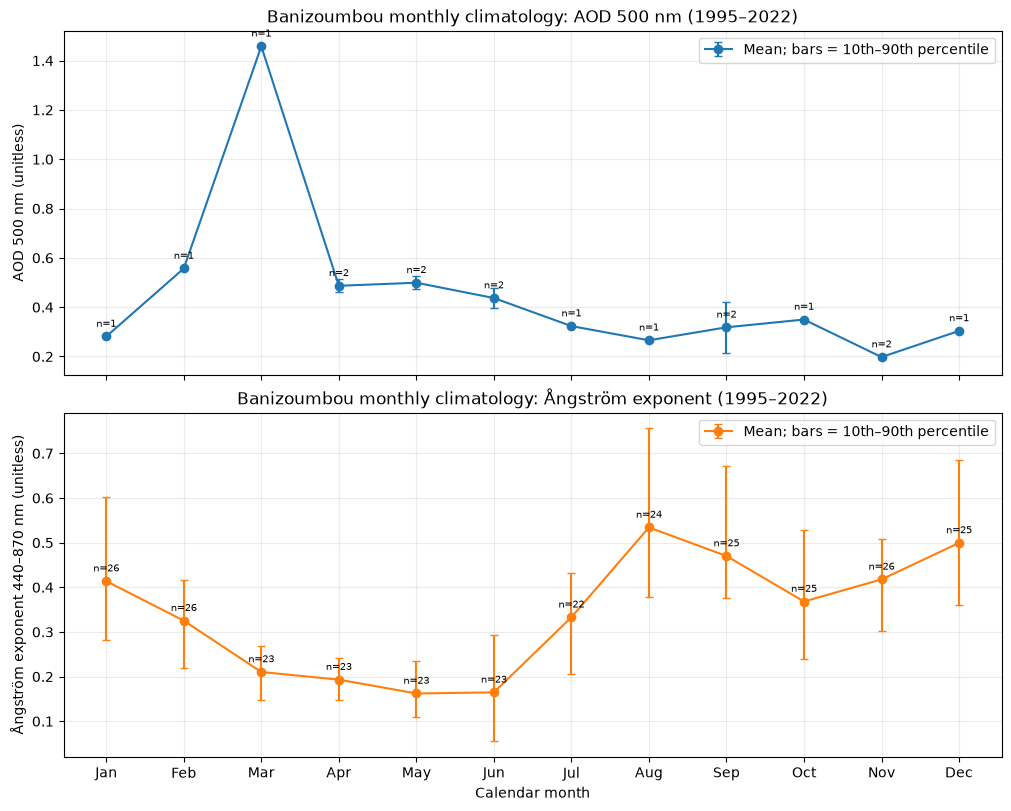


=== THIS QUESTION : 5 model calls, 5 tool calls | in 102419 (cache read 95280, write 7129) | out 3218 (reasoning 745) | $0.0083
=== CONVERSATION  : 10 model calls, 13 tool calls | in 157903 (cache read 134343, write 23540) | out 4811 (reasoning 1195) | $0.0158


In [17]:
r = await ask("Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.")

In [18]:
answer(r)

## Banizoumbou monthly climatology

**Skill used:** *climatology*  
**Threshold:** monthly means retained only when there were **at least 5 valid daily values**. The plotted error bars are the **10th–90th percentiles of retained yearly monthly means**.

- **Site:** Banizoumbou  
- **Coordinates:** 13.547° N, 2.665° E; elevation 274 m  
- **Overall period:** 1995-10-16 to 2022-11-25  
- **Wavelengths:** AOD at 500 nm; Ångström exponent at 440–870 nm  
- **Valid daily N:** 362 AOD-500 days; 6,581 Ångström-exponent days  
- **Retained monthly means:** 17 for AOD; 291 for Ångström exponent  

| Month | AOD 500 nm | AOD N years | Ångström exponent 440–870 nm | AE N years |
|---|---:|---:|---:|---:|
| Jan | 0.281 | 1 | 0.41 | 26 |
| Feb | 0.557 | 1 | 0.33 | 26 |
| Mar | 1.458 | 1 | 0.21 | 23 |
| Apr | 0.487 | 2 | 0.19 | 23 |
| May | 0.499 | 2 | 0.16 | 23 |
| Jun | 0.437 | 2 | 0.17 | 23 |
| Jul | 0.323 | 1 | 0.33 | 22 |
| Aug | 0.266 | 1 | 0.53 | 24 |
| Sep | 0.318 | 2 | 0.47 | 25 |
| Oct | 0.350 | 1 | 0.37 | 25 |
| Nov | 0.198 | 2 | 0.42 | 26 |
| Dec | 0.304 | 1 | 0.50 | 25 |

### Important coverage caveat

The AOD 500 nm record is highly uneven: the retained AOD monthly means occur only from **April 2021 through November 2022**, with several months represented by only one year. Therefore, the AOD seasonal pattern should not be interpreted as a robust long-term climatology. The Ångström-exponent climatology has much broader coverage, although the number of contributing years also varies by month.

The plot uses the mean monthly value with 10th–90th percentile bars and is saved as:

`/workspace/banizoumbou_monthly_climatology_AOD500_AE440_870.png`

The climatology table is saved as:

`/workspace/banizoumbou_monthly_climatology_AOD500_AE440_870.csv`

AERONET site PI acknowledgment: **Arnon Karnieli** (Banizoumbou).

In [19]:
sb.state(CONVERSATION_ID)

{'vars': {'cols': 'list',
  'df500': 'DataFrame(1419960, 6)',
  'valid': 'DataFrame(1250886, 6)',
  'summary': 'DataFrame(5, 7)',
  'top_sites': 'list',
  'pi_df': 'DataFrame(38148, 3)',
  'pi': 'DataFrame(5, 3)',
  'ban': 'DataFrame(6581, 9)',
  'annual': 'DataFrame(28, 3)',
  'monthly_climatology': 'function',
  'monthly_aod': 'DataFrame(17, 4)',
  'clim_aod': 'DataFrame(12, 8)',
  'monthly_ae': 'DataFrame(291, 4)',
  'clim_ae': 'DataFrame(12, 8)',
  'clim': 'DataFrame(12, 15)',
  'month_names': 'list',
  'clim_out': 'DataFrame(12, 16)',
  'fig': 'Figure',
  'axes': 'ndarray(2,)',
  'x': 'ndarray(12,)',
  'ax': 'Axes',
  'val': 'str',
  'label': 'str',
  'color': 'str',
  'title': 'str',
  'mean': 'ndarray(12,)',
  'lo': 'ndarray(12,)',
  'hi': 'ndarray(12,)',
  'n': 'ndarray(12,)',
  'yerr': 'ndarray(2, 12)',
  'xi': 'int8()',
  'yi': 'float64()',
  'ni': 'int64()'},
 'files': ['banizoumbou_monthly_climatology_AOD500_AE440_870.csv',
  'banizoumbou_monthly_climatology_AOD500_AE440_87

## 7 · Save / resume

`history` is plain data. Sandbox variables do not survive a container stop (60 idle minutes); files in
`conversation_data/conv_005/` do. After a resume, tell the model so in the first question.

In [ ]:
from pydantic_ai.messages import ModelMessagesTypeAdapter

MESSAGES_FILE = sb.CONV_DIR / CONVERSATION_ID / "messages.json"

def save_history():
    MESSAGES_FILE.write_bytes(ModelMessagesTypeAdapter.dump_json(history, indent=1))
    print(f"{len(history)} messages -> {MESSAGES_FILE}")

def load_history():
    global history
    history = ModelMessagesTypeAdapter.validate_json(MESSAGES_FILE.read_bytes())
    print(f"{len(history)} messages <- {MESSAGES_FILE}")

save_history()

In [ ]:
# tomorrow: run sections 1-5, then
# load_history()
# r = await ask("The kernel was restarted; earlier results are in /workspace. Where did we stop, and what do you still have on disk?")

## 8 · Cleanup

In [ ]:
sb.stop(CONVERSATION_ID)